# Model Optimization Notebook
 
In this notebook, we focus on optimizing a machine learning model for customer churn prediction. 
We will cover data processing, model training, evaluation, and threshold tuning to maximize performance.


### 1) Imports
- Data handling: pandas and numpy
- Visualization: matplotlib
- Machine learning: scikit-learn components for modeling, preprocessing, and evaluation
- Joblib for model persistence
- Internal modules for project setup, configuration, and preprocessing, ensuring that file paths and data preparation routines are accessible.
 
This step prepares the notebook by loading all required dependencies for data wrangling, analysis, model training, evaluation, and utility functions needed in the model optimization pipeline.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve, roc_curve, roc_auc_score
import joblib

import _setup
from src.config import DATA_PATH, MODEL_DIR, NUMERIC_COLS
from src.preprocess import preprocess

print('loaded all dependencies successfully...')

loaded all dependencies successfully...


### 2) Loading the data

In [31]:
# Load dataset and preprocess it

data = preprocess(pd.read_csv(DATA_PATH))

print('loaded data successfully...')

loaded data successfully...


### 3) Splitting and scaling of train and test sets

In [32]:
# Splitting Data and scaling train and test sets

X = data.drop('Churn', axis=1)
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train[NUMERIC_COLS] = scaler.fit_transform(X_train[NUMERIC_COLS])
X_test[NUMERIC_COLS] = scaler.transform(X_test[NUMERIC_COLS])

print('splitted and scaled train and test sets')

splitted and scaled train and test sets


### 4) Fitting the model

In [33]:
model = LogisticRegression(class_weight='balanced')

model.fit(X_train, y_train)

print('model fitted successfully...')

model fitted successfully...


### 5) Testing the model

In [34]:
y_pred = model.predict(X_test)

print('Test Results :-')
print(f'Accuracy = {accuracy_score(y_test, y_pred):.2f}')
print(f'Precision = {precision_score(y_test, y_pred):.2f}')
print(f'Recall = {recall_score(y_test, y_pred):.2f}')
print(f'F1 Score = {f1_score(y_test, y_pred):.2f}')

Test Results :-
Accuracy = 0.74
Precision = 0.50
Recall = 0.78
F1 Score = 0.61


### 6) Tuning the threshold
Experimented with different thresholds (0.3, 0.4, 0.6, 0.7), but found optimal results at 0.35

In [35]:
y_prob = model.predict_proba(X_test)[:, 1]
threshold = 0.35

y_pred_new = (y_prob >= threshold).astype(int)

print(f'Test Results (At threshold = {threshold}) :-')
print(f'Accuracy = {accuracy_score(y_test, y_pred_new):.2f}')
print(f'Precision = {precision_score(y_test, y_pred_new):.2f}')
print(f'Recall = {recall_score(y_test, y_pred_new):.2f}')
print(f'F1 Score = {f1_score(y_test, y_pred_new):.2f}')
print(f'AUC Score = {roc_auc_score(y_test, y_pred_new):.2f}')

Test Results (At threshold = 0.35) :-
Accuracy = 0.68
Precision = 0.45
Recall = 0.90
F1 Score = 0.60
AUC Score = 0.75


### 7) Visualizing Metrics

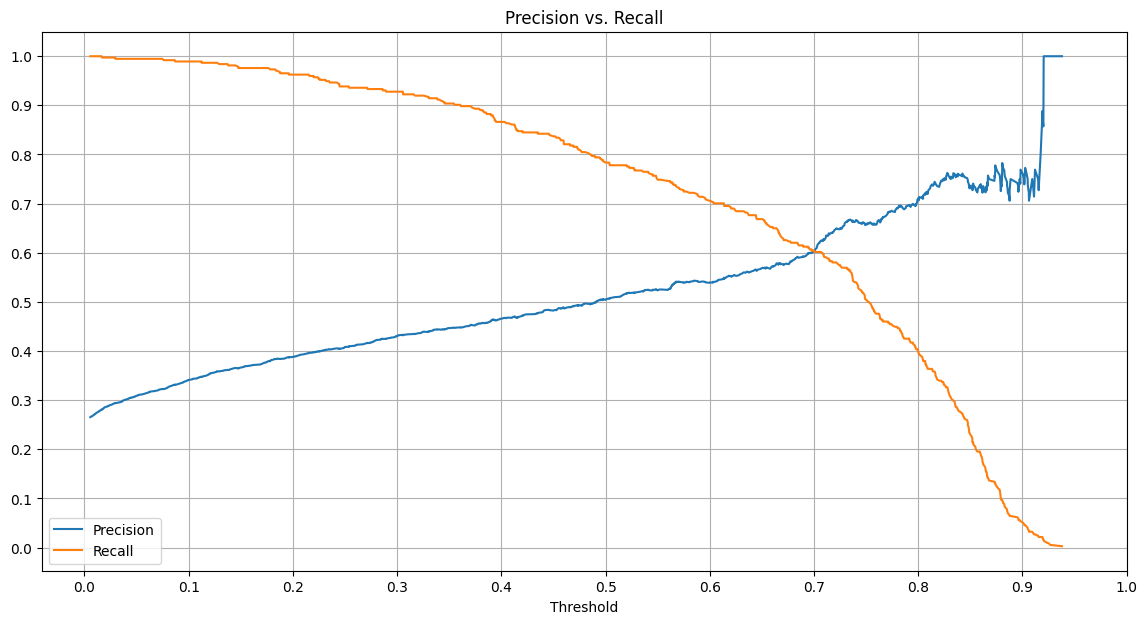

In [36]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

fig = plt.figure(figsize=(14,7))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.xticks(np.linspace(0, 1, 11))
plt.yticks(np.linspace(0, 1, 11))
plt.title('Precision vs. Recall')
plt.grid(True)
plt.legend()
plt.show()

Text(0.5, 1.0, 'ROC Curve')

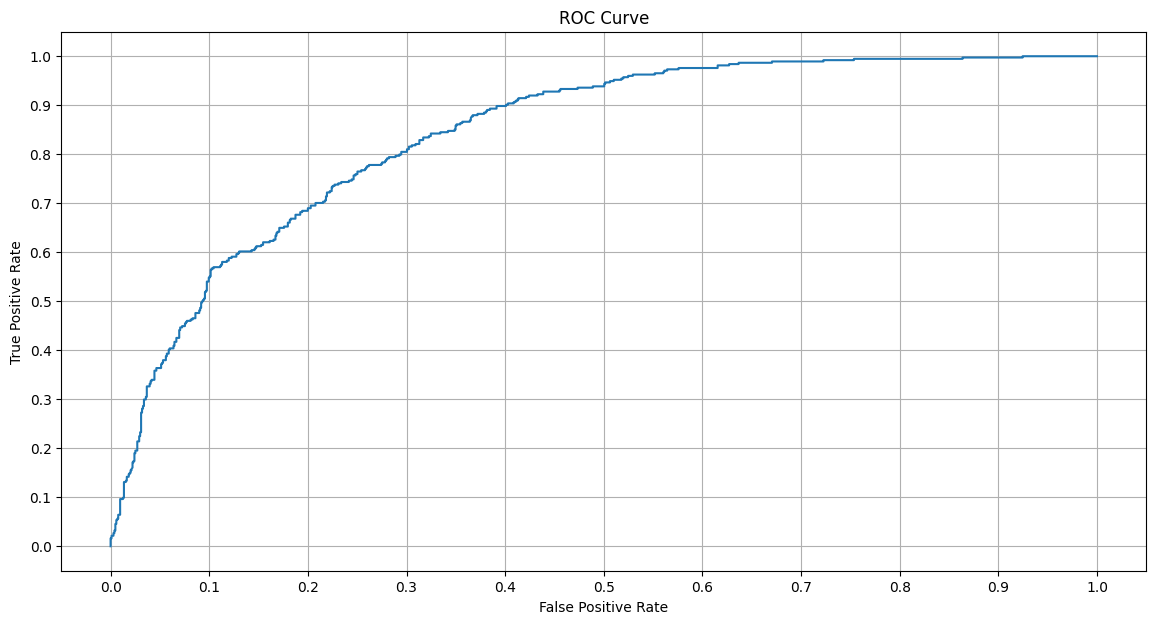

In [37]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

fig = plt.figure(figsize=(14,7))
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.xticks(np.linspace(0,1,11))
plt.yticks(np.linspace(0,1,11))
plt.grid(True)
plt.title('ROC Curve')

### Final Model Performance (After Threshold Tuning)

- **Recall:** 0.90  
- **Precision:** 0.45  
- **AUC:** 0.75  

### Final Observations

- The model successfully identifies 90% of customers likely to churn, making it highly effective for retention strategies.  
- Precision is moderate, indicating the presence of false positives, which is acceptable in churn prediction scenarios.  
- The AUC score of 0.75 indicates that the model has a good ability to distinguish between churners and non-churners.  
- The selected threshold (0.35) provides a strong balance between recall and precision, aligning with business priorities.

In [38]:
# Saving Model and Scaler

joblib.dump(model, MODEL_DIR/'model.pkl')
joblib.dump(X.columns, MODEL_DIR/'model_columns.pkl')
joblib.dump(scaler, MODEL_DIR/'scaler.pkl')

print('saved the model successfully...')

saved the model successfully...
